# Part III: Performance Comparison (15 points)
 ## 1.Create Dataset

In [18]:
using LinearAlgebra
using Random
using Distributions
using Revise
using Plots
includet("../src/src.jl")

function create_data(n::Int,d::Int)
    H =randn(n,d)
    # Whiten the covariates so that (1/n)X'X is approximately I_d
    S = (H' * H)/n
    F = eigen(Symmetric(S))
    W = F.vectors * Diagonal(1.0 ./ sqrt.(F.values)) * F.vectors'
    X = H*W

    beta = ones(d)
    eta = X*beta
    p = 1.0 ./ (1.0 .+ exp.(-eta))

    y = Float64.(rand.(Bernoulli.(p)))
    return X,y,beta
end


create_data (generic function with 1 method)

In [19]:
# a dataset with n = 10, 000 observations and d = 50 covariates.
n = 10000
d = 50
X, y, beta = create_data(n, d)

println("size(X) = ", size(X))
println("length(y) = ", length(y))
println("length(beta) = ", length(beta))
println("max entry of ((X'X)/n - I) = ", maximum(abs.((X' * X) / n - I)))
println("mean(y) = ", mean(y))

size(X) = (10000, 50)
length(y) = 10000
length(beta) = 50
max entry of ((X'X)/n - I) = 1.1324274851176597e-14
mean(y) = 0.5024


In [20]:
# We define first_bound to find when is the first step the function reach the threshold 
function first_hit(error_vals::Vector{Float64},eps::Float64)
    for i in eachindex(error_vals)
        if isfinite(error_vals[i]) && error_vals[i] <=eps
            return i-1
        end
    end
    return missing
end

first_hit (generic function with 1 method)

In [21]:

function evaluate_algorithms(;
    n::Int =10000,d::Int=50,alpha::Float64=0.3,beta::Float64=0.7,T_max::Int=200,T_ref::Int=400,seed::Int=2026)
    Random.seed!(seed)
    X,y,theta_true = create_data(n,d)
    eps = 0.001/n

    #We first run for longer time to get to the approximate optimum values
    _,f_ref,_,_= newton_ascent(y,X,T_ref,alpha,beta)
    # Main runs
    theta_g,f_g,etas_g,times_g = gradient_ascent(y,X,T_max,alpha,beta)
    theta_n,f_n,etas_n,times_n= newton_ascent(y,X,T_max,alpha,beta)

    #Use finite values when defining appropriate optimum,remove all the NaN and Inf
    finite_ref = f_ref[isfinite.(f_ref)]
    f_star = maximum(finite_ref)

    # We clip the gap below a constant, for log plots
    err_g = max.(f_star .-f_g,1e-16)
    err_n = max.(f_star .-f_n,1e-16)
    T_grad = first_hit(err_g,eps)
    T_newton = first_hit(err_n,eps)

    cumtime_g = [0.0;cumsum(times_g)]
    cumtime_n = [0.0;cumsum(times_n)]
    iters = 0:T_max

    #Plot the two plots
    p_iter = plot(iters,err_g,yscale=:log10,
    xlabel = "Number of iterations",
    ylabel="Error",
    label = "Gradient Ascent(Descent) Method",
    linewidth = 2,
    title = "Error vs iterations")
    plot!(p_iter,iters,err_n,label="Newton's Method",linewidth =2)
    hline!(p_iter,[eps],linestyle =:dash,label = "epsilon")

    # Plot-----------error vs time
    p_time = plot(
        cumtime_g, err_g,
        yscale = :log10,
        xlabel = "Total Elapsed Time (seconds)",
        ylabel = "Error",
        label = "Gradient Ascent",
        linewidth = 2,
        title = "Error vs Time"
    )
    plot!(p_time, cumtime_n, err_n, label = "Newton's Method", linewidth = 2)
    hline!(p_time, [eps], linestyle = :dash, label = "epsilon")

    println("epsilon = ", eps)
    println("approximate optimum f̂* = ", f_star)
    println("minimum T for Gradient Ascent = ", T_grad)
    println("minimum T for Newton's Method = ", T_newton)
    println("Gradient Ascent total time = ", cumtime_g[end])
    println("Newton's Method total time = ", cumtime_n[end])


    return (
    eps = eps,
    f_star = f_star,
    T_grad = T_grad,
    T_newton = T_newton,
    cumtime_grad = cumtime_g,
    cumtime_newton = cumtime_n,
    plot_iter = p_iter,
    plot_time = p_time
)
end

evaluate_algorithms (generic function with 8 methods)

epsilon = 1.0e-7
approximate optimum f̂* = -1680.2146882841532
minimum T for Gradient Ascent = 95
minimum T for Newton's Method = 8
Gradient Ascent total time = 41.974640600000015
Newton's Method total time = 9.216349399999997


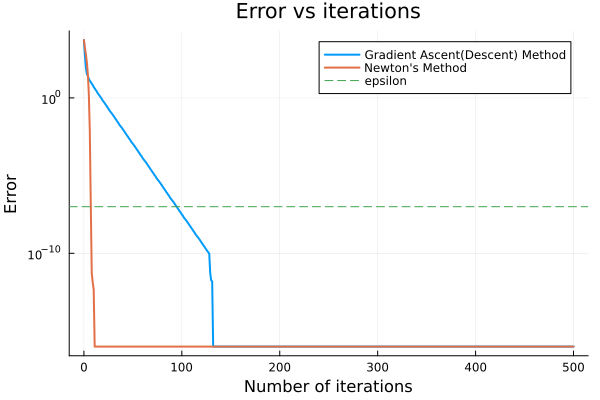

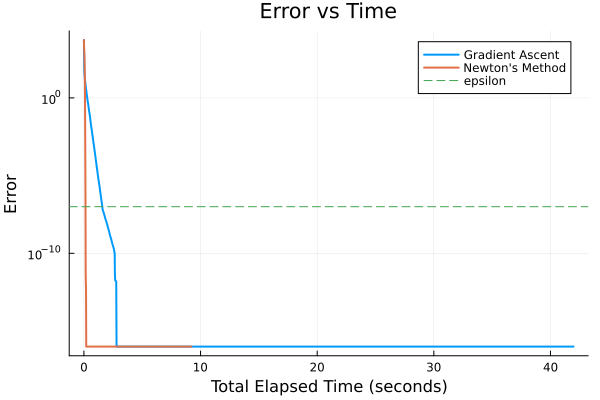

Minumum iterations for Gradient Ascent = 95
Minumum iterations for Newton's Method = 8
Gradient Ascent Total time = 41.974640600000015
Newton's Method Total time = 9.216349399999997
Gradient Ascent time to reach epsilon = 1.578112599999999
Newton's Method time to reach epsilon = 0.1523142


In [24]:
result = evaluate_algorithms(T_max =500,T_ref = 300)
display(result.plot_iter)
display(result.plot_time)

println("Minumum iterations for Gradient Ascent = ", result.T_grad)
println("Minumum iterations for Newton's Method = ", result.T_newton)
println("Gradient Ascent Total time = ",result.cumtime_grad[end])
println("Newton's Method Total time = ",result.cumtime_newton[end])
println("Gradient Ascent time to reach epsilon = ", result.cumtime_grad[result.T_grad + 1])
println("Newton's Method time to reach epsilon = ", result.cumtime_newton[result.T_newton + 1])

## 2. Compare Algorithms